## Define functions

In [1]:
import numpy as np
import pandas as pd
from scipy import signal
import os
import matplotlib.pyplot as plt

# --- Load Data ---
def load_data(file_path):
    """
    Loads timestamped accelerometer data from a CSV file.

    Args:
        file_path (str): Path to the input data file.

    Returns:
        pd.DataFrame: DataFrame containing columns ['x', 'y', 'z', 'timestamp'].
    """
    return pd.read_csv(file_path, names=['x', 'y', 'z', 'timestamp'])

# --- Interpolation Method ---
def align_by_interpolation(ref_df, align_df):
    """
    Aligns align_df to ref_df's timestamps using linear interpolation.

    Args:
        ref_df (pd.DataFrame): Reference dataframe with target timestamps.
        align_df (pd.DataFrame): Dataframe to align using interpolation.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (ref_df, interpolated_aligned_df)
    """
    interp_df = pd.DataFrame()
    interp_df['timestamp'] = ref_df['timestamp']
    interp_df['x'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['x'])
    interp_df['y'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['y'])
    interp_df['z'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['z'])
    interp_df = interp_df[['x', 'y', 'z', 'timestamp']]
    return ref_df, interp_df

# --- Save Aligned Data ---
def save_aligned_data(df_55, df_193, output_path):
    """
    Saves aligned data from two dataframes into a single CSV file in the order 55 then 193.

    Args:
        df_55 (pd.DataFrame): Aligned data from device 55.
        df_193 (pd.DataFrame): Aligned data from device 193.
        output_path (str): Path to save the output file.
    """
    aligned = pd.concat([df_55.add_suffix('_1'), df_193.add_suffix('_2')], axis=1)
    aligned.to_csv(output_path, index=False)
    print(f"Saved aligned data to {output_path}")

# --- Load, align and save ---
def load_align_save(distance):
    """
    Loads, aligns, and saves accelerometer data for multiple pairs of recordings,
    always saving in the order (55, 193) but aligning using the device with fewer samples.

    Args:
        distance (str): Distance label used in filenames (e.g., '50', '155').
    """
    for i in range(1, 6):
        df_55 = load_data(f'{distance}_{i}_55.txt')
        df_193 = load_data(f'{distance}_{i}_193.txt')

        # Prevent extrapolation by choosing the smaller one as reference
        if len(df_55) <= len(df_193):
            ref_df, aligned_df = align_by_interpolation(df_55, df_193)
        else:
            ref_df, aligned_df = align_by_interpolation(df_193, df_55)

        # Ensure df_55 is always saved as _1 and df_193 as _2
        if ref_df.equals(df_55):
            save_aligned_data(ref_df, aligned_df, f'aligned_{distance}_{i}.txt')
        else:
            save_aligned_data(aligned_df, ref_df, f'aligned_{distance}_{i}.txt')


# --- High-Pass Filter ---
def hpf(data, cutoff_freq, Fs, order):
    """
    Applies a high-pass Butterworth filter to the input signal.

    Args:
        data (array-like): Input signal (e.g., x, y, or z axis).
        cutoff_freq (float): Cutoff frequency in Hz.
        Fs (float): Sampling frequency in Hz.
        order (int): Order of the Butterworth filter.

    Returns:
        np.ndarray: Filtered signal.
    """
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = signal.butter(order, normal_cutoff, btype='highpass')
    return signal.filtfilt(b, a, data)


def load_all_aligned_data_to_dict(file_prefixes):
    """
    Loads all aligned data files matching each prefix into a dictionary of DataFrames.
    
    Args:
        file_prefixes (List[str]): List of file name prefixes (e.g., ['263', 'static']).
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary of label -> DataFrame.
    """
    dfs = {}
    for prefix in file_prefixes:
        for i in range(1, 6):
            file_path = f'aligned_{prefix}_{i}.txt'
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, names=[
                    'x1', 'y1', 'z1', 'timestamp1', 'x2', 'y2', 'z2', 'timestamp2'
                ], dtype=str)  # Read as string first to avoid DtypeWarning

                # Convert all columns to numeric safely
                for col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                # Drop any rows with NaNs if needed
                df = df.dropna().reset_index(drop=True)

                key = f"{prefix}_{i}"
                dfs[key] = df
            else:
                print(f"File not found: {file_path}")
    return dfs


def compute_and_plot_csd(data_dict, fs=3200):
    """
    Computes total acceleration and cross-spectral density between device 1 and device 2.
    Plots the magnitude of the cross-spectral density for each aligned dataset.

    Args:
        data_dict (dict): Dictionary of aligned DataFrames. Each DataFrame must have:
                          ['x1', 'y1', 'z1', 'timestamp1', 'x2', 'y2', 'z2', 'timestamp2']
        fs (float): Sampling frequency in Hz (default 3200).

    Returns:
        dict: Dictionary where each key contains:
              - 'f': frequencies
              - 'Pxy': complex-valued cross spectral density
              - 'magnitude': magnitude of Pxy
    """
    results = {}

    for label, df in data_dict.items():
        # Compute total acceleration
        a1 = np.sqrt(df['x1']**2 + df['y1']**2 + df['z1']**2)
        a2 = np.sqrt(df['x2']**2 + df['y2']**2 + df['z2']**2)

        # Compute CSD
        f, Pxy = signal.csd(a1, a2, fs=fs, nperseg=1024)

        # Save result
        results[label] = {
            'f': f,
            'Pxy': Pxy,
            'magnitude': np.abs(Pxy)
        }

        # Plot
        plt.figure(figsize=(8, 4))
        plt.plot(f, np.abs(Pxy))
        plt.title(f'CSD Magnitude - {label}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('|CSD|')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return results

## Import and Align data

In [3]:
import pandas as pd

load_align_save(263)
load_align_save(155)
load_align_save(50)
load_align_save('static')

Saved aligned data to aligned_263_1.txt
Saved aligned data to aligned_263_2.txt
Saved aligned data to aligned_263_3.txt
Saved aligned data to aligned_263_4.txt
Saved aligned data to aligned_263_5.txt
Saved aligned data to aligned_155_1.txt
Saved aligned data to aligned_155_2.txt
Saved aligned data to aligned_155_3.txt
Saved aligned data to aligned_155_4.txt
Saved aligned data to aligned_155_5.txt
Saved aligned data to aligned_50_1.txt
Saved aligned data to aligned_50_2.txt
Saved aligned data to aligned_50_3.txt
Saved aligned data to aligned_50_4.txt
Saved aligned data to aligned_50_5.txt
Saved aligned data to aligned_static_1.txt
Saved aligned data to aligned_static_2.txt
Saved aligned data to aligned_static_3.txt
Saved aligned data to aligned_static_4.txt
Saved aligned data to aligned_static_5.txt


## Analyze data and Plotting

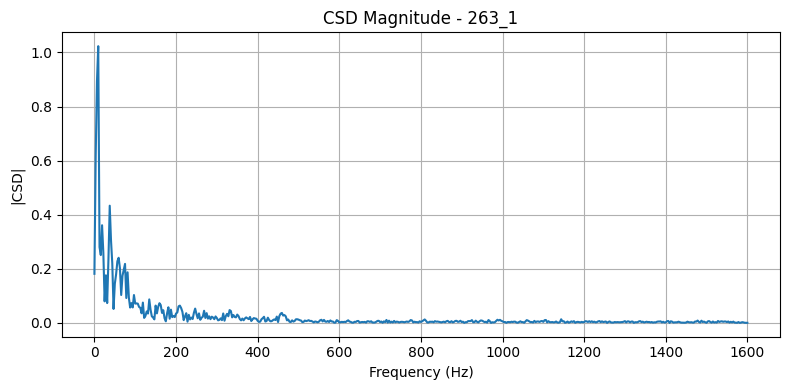

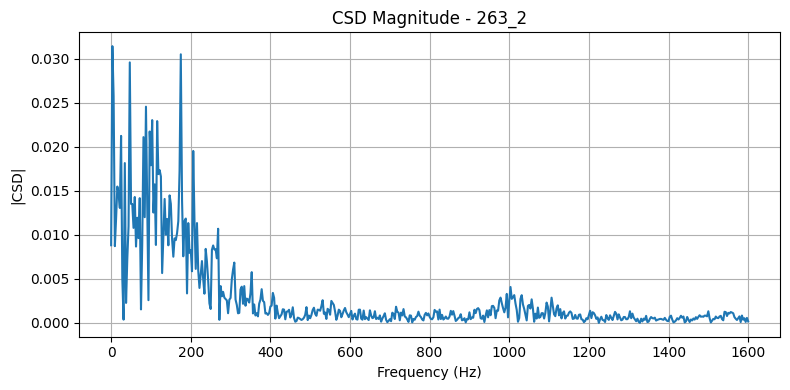

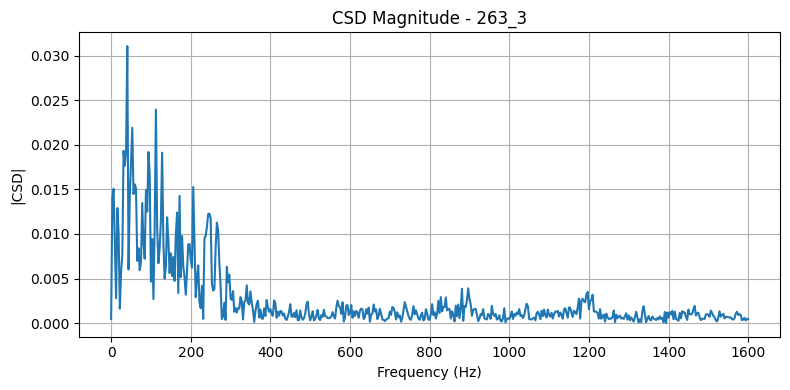

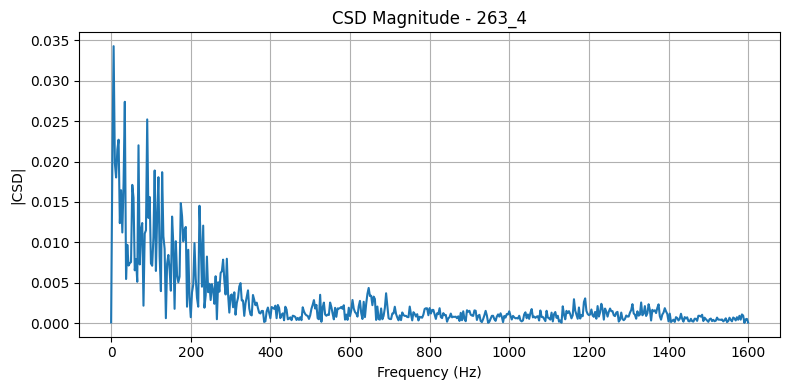

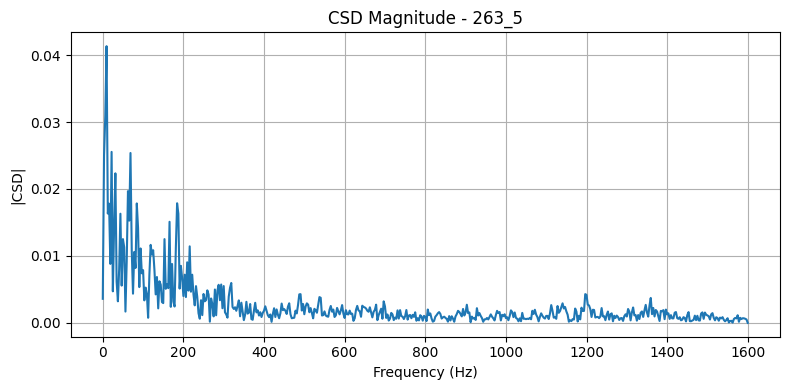

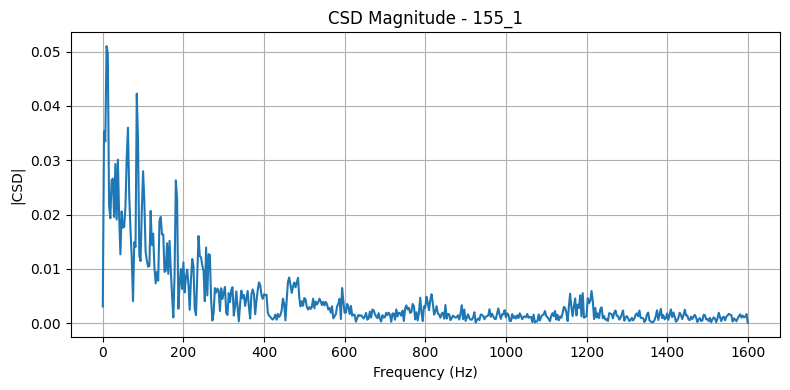

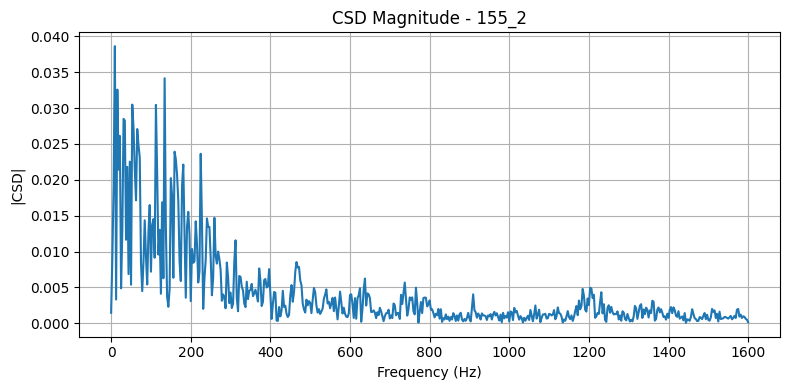

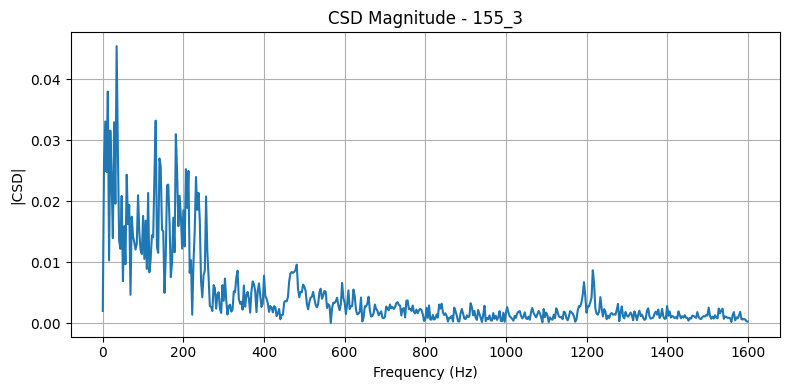

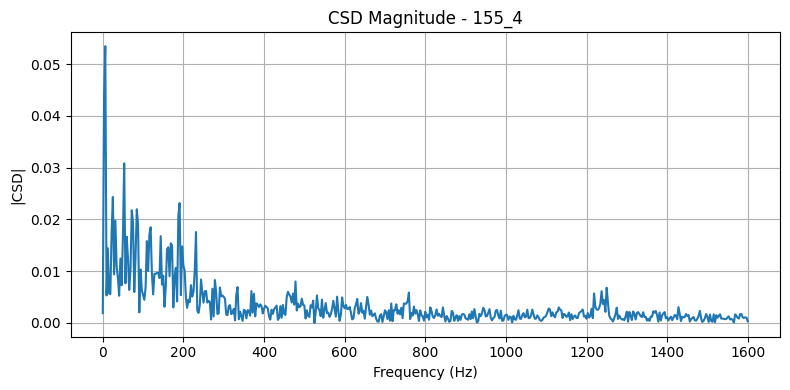

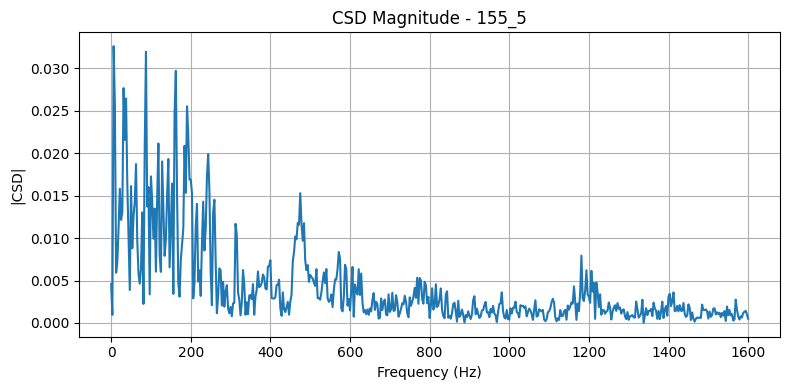

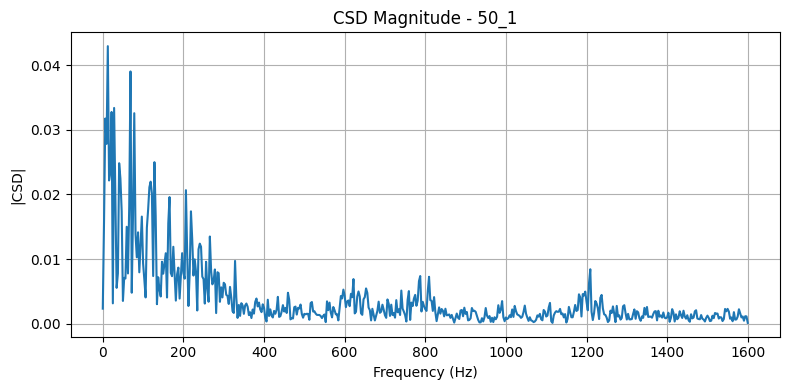

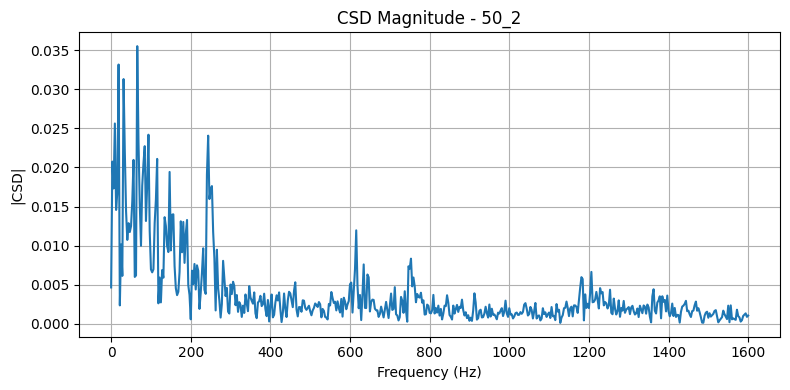

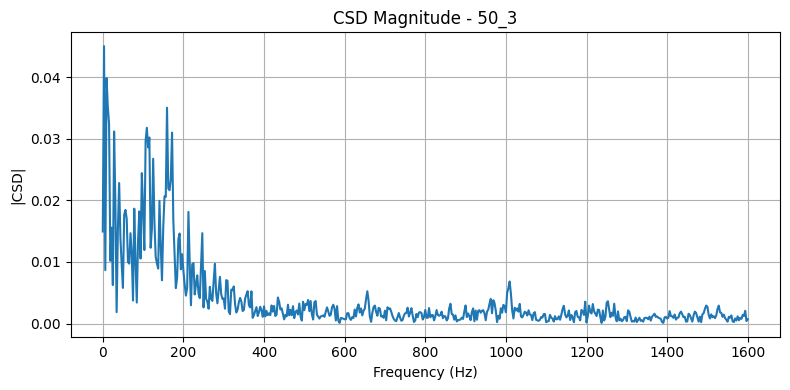

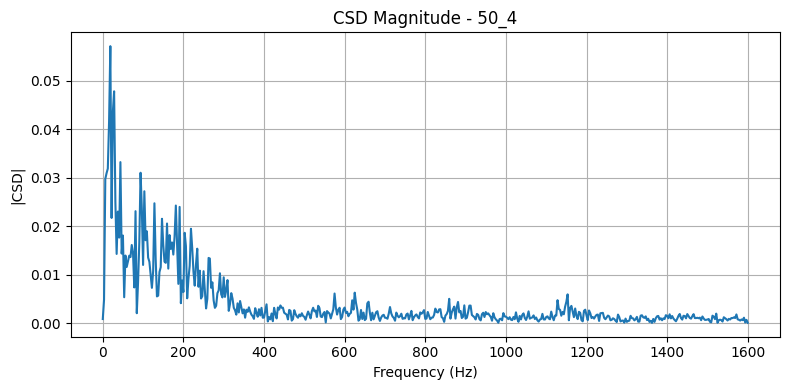

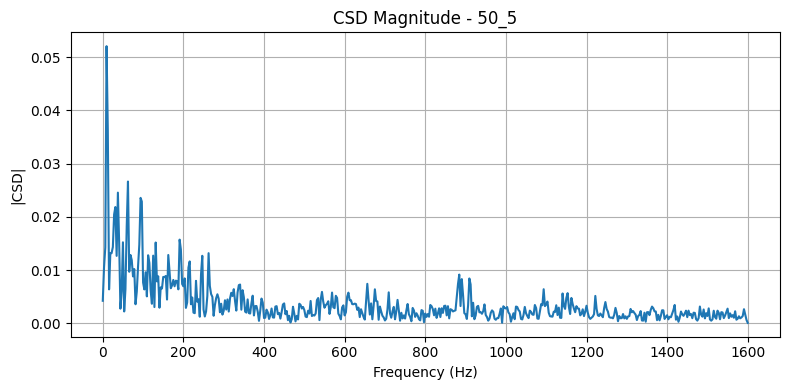

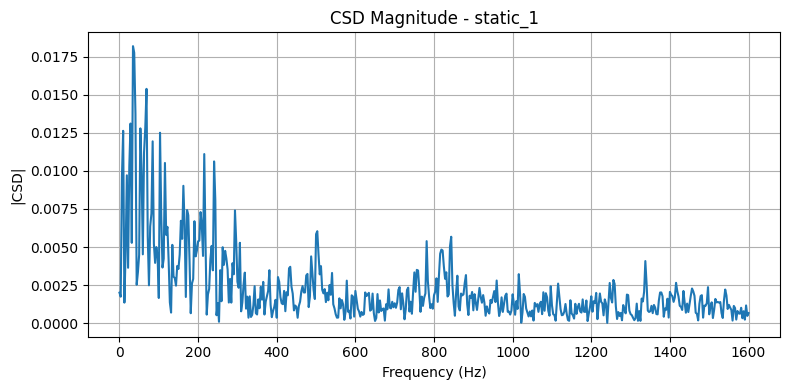

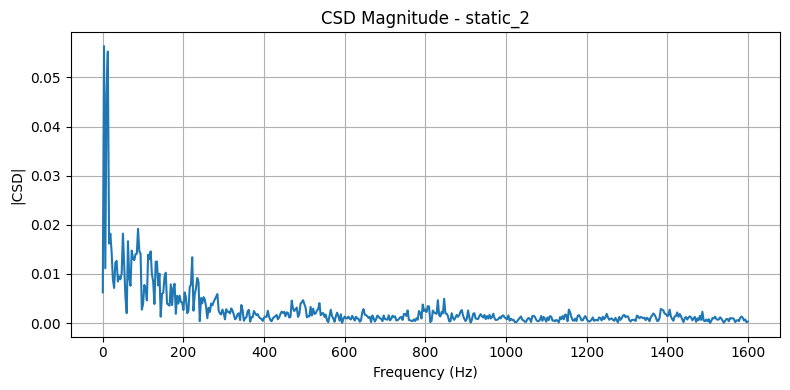

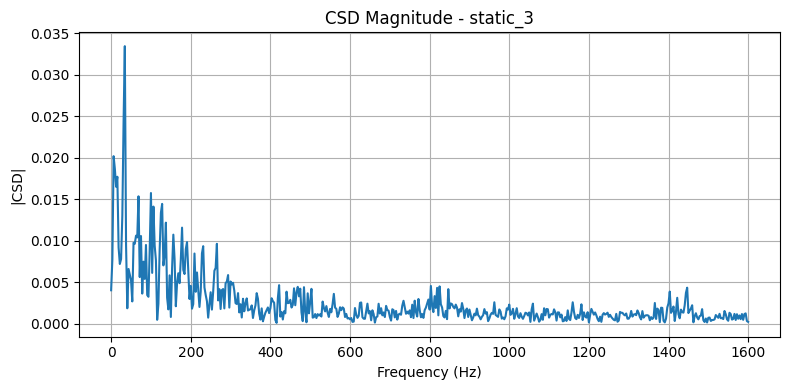

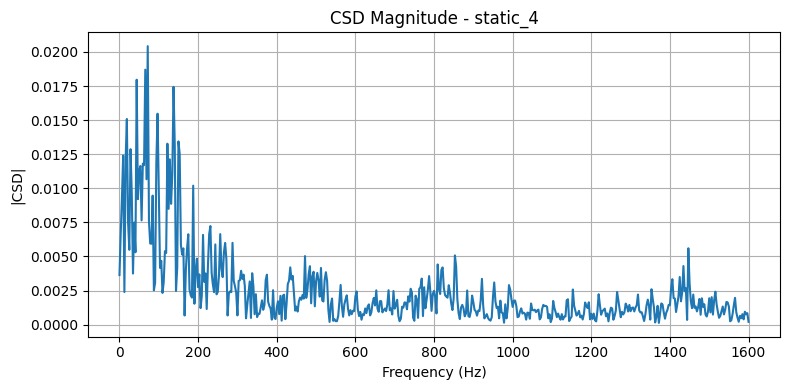

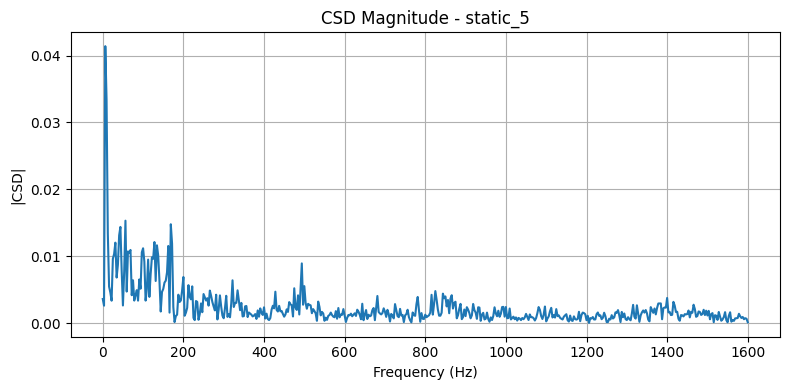

In [2]:
file_prefixes = ['263', '155', '50', 'static']
data_dict = load_all_aligned_data_to_dict(file_prefixes)

csd_results = compute_and_plot_csd(data_dict)


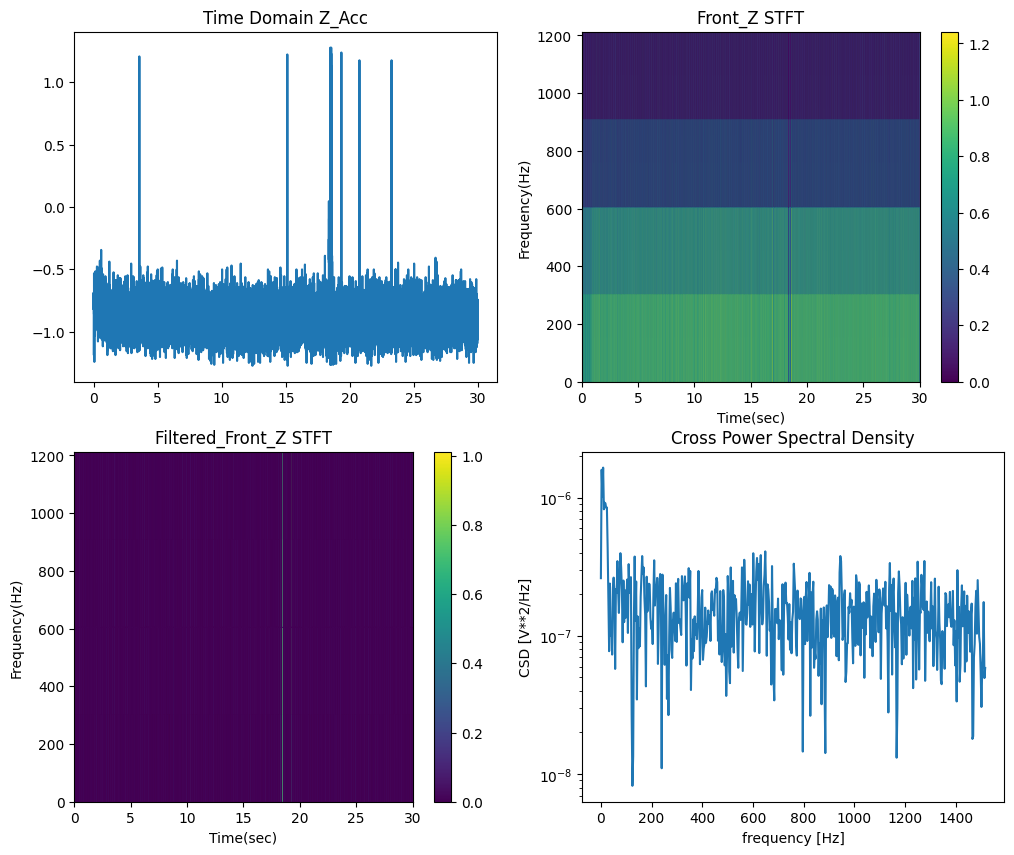

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import datetime
import numpy as np


# parameters
N = data_dict['df_263_1'].shape[0] # number of samples
Fs = N / 30 # sampling rate
T = 1 / Fs  # Sampling interval
t = np.arange(0, 30, T)  # Time vector (1 second)
# d = Fs/N # freqeuncy spacing of FFT

# axis
# time_axis = df['Time(s)']
freqs_axis = np.fft.fftfreq(N, T)

# Front acc 
front_zacc = df['Z_front(g)'] # z-axis acceleration of front one
fft_front = np.fft.fft(front_zacc) # FFT of original front z-axis
# front_magnitude = np.abs(fft_front)
front_magnitude = np.sqrt(**2 + y**2 + z**2)

# filter low frequency of the signal
front_zacc_filtered = hpf(front_zacc, 50, Fs, 3)

# FFT of filtered signals
fft_filtered_front = np.fft.fft(front_zacc_filtered)
filtered_abs = np.abs(fft_filtered_front)

# Rear acc
rear_zacc = df['Z_rear(g)'] # z-axis acceleration of rear one
fft_rear = np.fft.fft(rear_zacc) # FFT of original rear z-axis
rear_magnitude = np.abs(fft_rear)

# filter low frequency of the signal
front_zacc_filtered = hpf(front_zacc, 50, Fs, 3)
rear_zacc_filtered = hpf(rear_zacc, 50, Fs, 3)

# FFT of filtered signals
fft_filtered_front = np.fft.fft(front_zacc_filtered)
filtered_abs_front = np.abs(fft_filtered_front)
fft_filtered_rear = np.fft.fft(rear_zacc_filtered)
filtered_abs_rear = np.abs(fft_filtered_rear)

# plot the signals
fig = plt.figure(figsize=(12, 10))  # Adjust the width and height as needed
plt.subplot(221)
plt.plot(t, front_zacc)
plt.title('Time Domain Z_Acc')


# Short Time Fourier Transform of the signals
f, t, zfront_stft = signal.stft(front_zacc, Fs, nperseg=5)
f_filterd, t_filtered, zfront_stft_filtered = signal.stft(front_zacc_filtered, Fs, nperseg=5)

plt.subplot(222)
plt.pcolormesh(t, f, np.abs(zfront_stft), vmin=0, shading='gouraud')
plt.title('Front_Z STFT')
plt.xlabel('Time(sec)')
plt.ylabel('Frequency(Hz)')
plt.colorbar()

plt.subplot(223)
plt.pcolormesh(t_filtered, f_filterd, np.abs(zfront_stft_filtered), vmin=0, shading='gouraud')
plt.title('Filtered_Front_Z STFT')
plt.xlabel('Time(sec)')
plt.ylabel('Frequency(Hz)')
plt.colorbar()

plt.subplot(224)
plt.title('Cross Power Spectral Density')
f, Pxy = signal.csd(front_zacc, rear_zacc, Fs, nperseg=1024) # Cross power spectral by Welch's method
plt.semilogy(f, np.abs(Pxy))
plt.xlabel('frequency [Hz]')
plt.ylabel('CSD [V**2/Hz]')
plt.show()


plt.tight_layout(rect=[0, 0.5, 1, 0.5])
plt.show()

## Define 1-D TDOA function

In [ ]:
def compute_1d_tdoa(source, receiver1, receiver2, speed_of_sound=343):
    """
    Compute the TDOA (Time Difference of Arrival) in 1D.

    Parameters:
    - source: Scalar position of the sound source (e.g., x-coordinate).
    - receiver1: Scalar position of the first receiver (e.g., x-coordinate).
    - receiver2: Scalar position of the second receiver (e.g., x-coordinate).
    - speed_of_sound: Speed of sound in m/s (default is 343 m/s).

    Returns:
    - tdoa: Time difference of arrival in seconds.
    """
    # Calculate distances from the source to each receiver
    distance1 = abs(source - receiver1)
    distance2 = abs(source - receiver2)

    # Compute TDOA
    tdoa = (distance2 - distance1) / speed_of_sound
    
    return tdoa

# Example usage
source_position = 10  # Position of the source (e.g., 10 meters)
receiver1_position = 2  # Position of the first receiver
receiver2_position = 20  # Position of the second receiver
tdoa = compute_1d_tdoa(source_position, receiver1_position, receiver2_position)
print(f"TDOA: {tdoa:.6f} seconds")
